# Visualize Images/Masks and Compare Feature Distributions

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import os
import glob
from matplotlib.ticker import MultipleLocator
import matplotlib.patches as mpatches
# import configs.config_oasis as config_oasis
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from torchvision.io import read_image
import random
import torchvision.transforms.functional as F
import numpy as np
from matplotlib.ticker import PercentFormatter
from skimage.measure import label, regionprops
from scipy.spatial.distance import pdist
import torchvision

In [3]:
#source: https://pytorch.org/vision/0.11/auto_examples/plot_visualization_utils.html
def show(imgs, name):
    if not isinstance(imgs, list):
        imgs = [imgs]
    size = 10 #4
    fig, axs = plt.subplots(ncols=len(imgs), squeeze=False, figsize=(len(imgs)*size, size))
    for i, img in enumerate(imgs):
        img = img.detach()
        img = F.to_pil_image(img)
        axs[0, i].imshow(np.asarray(img))
        axs[0, i].set(xticklabels=[], yticklabels=[], xticks=[], yticks=[])
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.axis('off')


# Visualize Images and Masks
The code below loads images and masks, and plots them. 

## Show S-SYNTH images

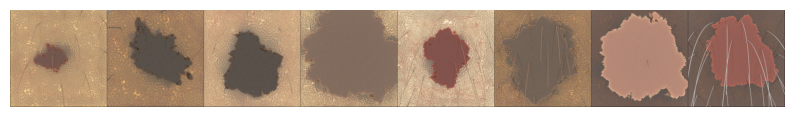

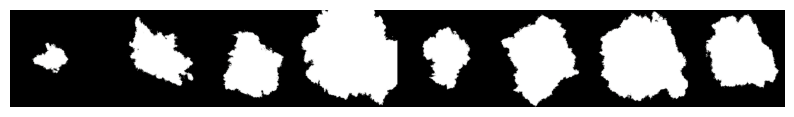

In [12]:
img_l = ['../../data/synthetic_dataset/10k_None/output/skin_063/hairModel_012/mel_0.19/fB_0.002/lesion_2/T_015/HbO2x0.5Epix0.15/hairAlb_0.84-0.6328-0.44/lesionScale_1.5/light_diffuse/origin_y_15.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_092/hairModel_020/mel_0.24/fB_0.002/lesion_11/T_025/HbO2x0.1Epix0.4/hairAlb_0.57-0.57-0.57/lesionScale_1.5/light_diffuse/origin_y_13.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_024/hairModel_051/mel_0.09/fB_0.05/lesion_3/T_035/HbO2x0.1Epix0.4/hairAlb_0.57-0.57-0.57/lesionScale_1.5/light_diffuse/origin_y_13.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_009/hairModel_046/mel_0.37/fB_0.002/lesion_11/T_055/HbO2x0.1Epix0.1/hairAlb_0.57-0.57-0.57/lesionScale_1.5/light_diffuse/origin_y_13.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_005/hairModel_095/mel_0.21/fB_0.005/lesion_9/T_025/HbO2x1.0Epix0.1/hairAlb_0.84-0.6328-0.44/lesionScale_1.5/light_diffuse/origin_y_15.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_084/hairModel_011/mel_0.37/fB_0.002/lesion_5/T_040/HbO2x0.1Epix0.15/hairAlb_0.84-0.6328-0.44/lesionScale_1.5/light_diffuse/origin_y_14.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_087/hairModel_093/mel_0.48/fB_0.002/lesion_7/T_055/HbO2x0.1Epix0.025/hairAlb_0.57-0.57-0.57/lesionScale_1.5/light_diffuse/origin_y_13.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png',
         '../../data/synthetic_dataset/10k_None/output/skin_012/hairModel_058/mel_0.41/fB_0.02/lesion_11/T_045/HbO2x0.5Epix0.05/hairAlb_0.9-0.9-0.9/lesionScale_1.5/light_diffuse/origin_y_15.0/mi_cuda_spectral/frame_-1/calChart_-1/ruler_-1/image.png']
    
grid = make_grid([read_image(img) for img in img_l])
show(grid, name='image_' + artifact)
grid = make_grid([read_image(img.replace("image.", "mask.")) for img in img_l])
name = 'mask_' + artifact
show(grid, name=name)


## Show HAM images

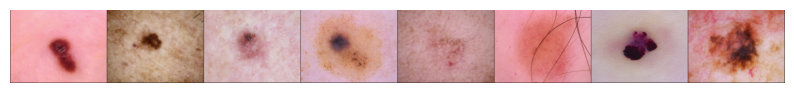

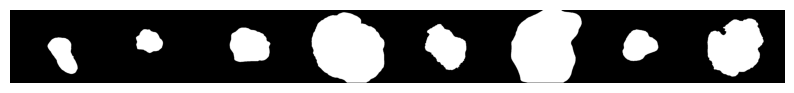

In [13]:
num_examples = 8
artifact_l = ["None"]
ham_path = '../../data/real_dataset/HAM10k/'


img_l = [ham_path + img_name for img_name in ['HAM10000_images_part_1/ISIC_0024888.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0026400.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0028980.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0026427.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0025368.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0026357.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0025924.jpg', 
                                                     'HAM10000_images_part_1/ISIC_0025732.jpg']]

ham_msk_path_root = ham_path + '/HAM10000_segmentations_lesion_tschandl'
mask_l = [
    f'{ham_msk_path_root}/{os.path.splitext(os.path.basename(path))[0]}_segmentation.png'
    for path in img_l
]

grid = make_grid([read_image(img) for img in img_l])
show(grid, name='image_' + artifact)
grid = make_grid([read_image(msk) for msk in mask_l])
name = 'mask_' + artifact
show(grid, name=name)

## Show ISIC images

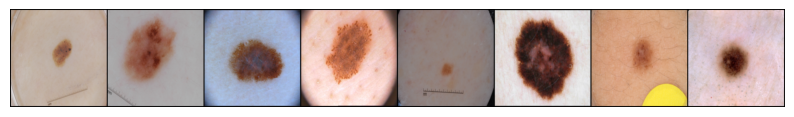

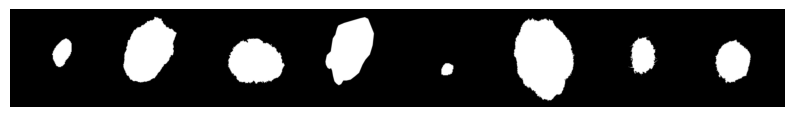

In [14]:
num_examples = 8
isic_path = '../../data/real_dataset/ISIC2018/'


img_l = [isic_path + img_name for img_name in ['ISIC2018_Task1-2_Training_Input/ISIC_0014029.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0000507.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0000034.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0000341.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0013517.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0000029.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0002438.jpg', 
                                              'ISIC2018_Task1-2_Training_Input/ISIC_0015298.jpg']]

isic_msk_path_root = isic_path + '/ISIC2018_Task1_Training_GroundTruth'
mask_l = [
    f'{isic_msk_path_root}/{os.path.splitext(os.path.basename(path))[0]}_segmentation.png'
    for path in img_l
]

grid = make_grid([torchvision.transforms.Resize((200,200))(read_image(img)) for img in img_l])
show(grid, name='')
grid = make_grid([torchvision.transforms.Resize((200,200))(read_image(msk)) for msk in mask_l])
show(grid, name='')

# Visualize feature histograms
The following code loads images and masks, and plots feature histograms 

In [15]:
from tqdm import tqdm
from torchvision.io.image import ImageReadMode
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import PercentFormatter

def get_mask_path(test_dataset, data_dir, image_path):
    image_ID = image_path.split('/')[-1].replace('.jpg', '')
    if test_dataset == "real_ISIC":
        image_ID = image_path.split('/')[-1].replace('.jpg','')
        mask_path = os.path.join(data_dir +  'ISIC2018_Task1_Training_GroundTruth/' + image_ID + '_segmentation' +'.png')
    elif test_dataset == "real_HAM":
        nameimage_path = image_path
        if "HAM10000_images_part_1" in nameimage_path:
            mask_path = nameimage_path.replace("/HAM10000_images_part_1/", "/HAM10000_segmentations_lesion_tschandl/")
            mask_path = mask_path.replace(".jpg", "_segmentation.png")
        else:
            nameimage_path = image_path
            mask_path = nameimage_path.replace("/HAM10000_images_part_2/", "/HAM10000_segmentations_lesion_tschandl/")
            mask_path = mask_path.replace(".jpg", "_segmentation.png")
    elif (test_dataset == "synth_regular") or (test_dataset == "synth_irregular"):
        mask_path = image_path.replace('image.png','mask.png')            
    return mask_path

def calculate_contrast(image, mask):
    # image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # in new version image is already in RGB format
    image = np.array(image)
    mask_bw = (np.array(mask)>0).astype('uint8')
    intensity_skin = np.mean(image[mask_bw == 0])
    intensity_lesion = np.mean(image[mask_bw == 1])
    contrast = abs(intensity_skin - intensity_lesion)
    return contrast

def calculate_diameter(mask):
    mask_bw = mask[:,:,0]>0
    regions = regionprops(mask_bw.astype(int))
    coords = regions[0].coords
    distances = pdist(coords, 'euclidean')
    return distances.max()

def calculate_perimeter(mask):
    mask_bw = mask[:,:,0]>0
    regions = regionprops(mask_bw.astype(int))
    return regions[0].perimeter

def calculate_area(mask):
    mask_bw = mask[:,:,0]>0
    regions = regionprops(mask_bw.astype(int))
    lesion_area = regions[0].area
#     mask_area = np.shape(mask_bw)[0]*np.shape(mask_bw)[1]
    return lesion_area

def get_eccentircity(mask): 
    mask_bw = mask[:,:,0]>0
    regions = regionprops(mask_bw.astype(int))
    return regions[0].eccentricity

# Color 
# Source: https://ietresearch.onlinelibrary.wiley.com/doi/epdf/10.1049/iet-ipr.2015.0385
# Source: http://www.wseas.us/e-library/conferences/2006bucharest/papers/518-442.pdf

colors = {'white': [255, 255, 255],
          'black': [0,0,0],
          'red': [205, 133, 63],
          'light_brown': [163, 82, 16],
          'dark_brown': [101, 67, 33],
          'blue_gray': [0, 134, 139],
         }
def get_color_distance(r,g,b, color):
    color = [num/255 for num in color] #normalize rgb colors
    return  np.sqrt((color[0]-r)**2 + (color[1]-g)**2 + (color[2]-b)**2)

def get_pixel_color(colors, r, g, b):
    suspicious_color = 'none'
    min_color_distance = 3
    for color_name in colors.keys():
        color_rgb = colors[color_name]
        color_distance = get_color_distance(r, g, b, color_rgb)
        if color_distance < min_color_distance:
            min_color_distance = color_distance
            suspicious_color = color_name
    if min_color_distance < 0.4:
        return suspicious_color
    else:
        return 'none'
    
# get the individual l a b values for lesion and skin (change "lesion" to False to calculate skin values)

def get_lab_values(image, mask, lesion=True):
    # image_lab = cv2.cvtColor(image,cv2.COLOR_BGR2LAB)
    image_lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)  # LAB format

    if lesion == True: # get the values for the lesion or background skin
        mask = np.where(mask[:,:,0]>1, 1, 0)
    else:
        mask = np.where(mask[:,:,0]>1, 0, 1)
    mask = np.repeat(mask[:,:,np.newaxis], 3, axis=2)
    image_lab = image_lab * mask # get lesion image
    l_channel = []
    a_channel = []
    b_channel = []
    k = 0
    for i in range(image_lab.shape[0]):
        for j in range(image_lab.shape[1]):
            l, a, b = image_lab[i,j,:]
            if ((l == 0) and (a ==0) and (b == 0)): 
                pass
            else:
                l_channel.append(l/255*100)
                a_channel.append(a)
                b_channel.append(b)
                # a_channel.append(a-128)
                # b_channel.append(b-128)

                k += 1
    l = np.mean(l_channel)
    a = np.mean(a_channel)
    b = np.mean(b_channel)
    return [l, a, b]    

# Calculate symmetry:
# Source: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC7516968/pdf/entropy-22-00484.pdf
# Source: https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=6115757&tag=1

def get_sym(mask, degree):
    center = regionprops(mask)[0].centroid[:-1]
    rotation_matrix = cv2.getRotationMatrix2D(center[::-1], degree, 1.0)
    rotated_mask = cv2.warpAffine(mask, rotation_matrix, (mask.shape[1], mask.shape[0]))
    A = cv2.bitwise_or(mask, rotated_mask)
    FS = A - mask
    sym = 1-(np.sum(FS)/np.sum(A))
    return sym

def get_symmetry(mask):
    sym180 = get_sym(mask, 180)
    sym90 = get_sym(mask, 90)
    return 0.5 * (sym180 + sym90)

def get_features(image_path, mask_path):
    # image = cv2.imread(image_path) # this was the incorrect old version
    image = read_image(image_path, ImageReadMode.RGB)
    image = image.permute(1, 2, 0).numpy()  # [H, W, C], still uint8

    mask = cv2.imread(mask_path)
    eccentircity = get_eccentircity(mask)
    symmetry = get_symmetry(mask)
    image = cv2.resize(image, (128,128))
    mask = cv2.resize(mask, (128,128))
    
    contrast = calculate_contrast(image, mask)
    diameter = calculate_diameter(mask)
    area = calculate_area(mask)
    perimeter = calculate_perimeter(mask)
    lesion_lab = get_lab_values(image, mask, lesion=True)
    skin_lab = get_lab_values(image, mask, lesion=False)
    return contrast, diameter, area, perimeter, eccentircity, symmetry, lesion_lab, skin_lab

def create_image_feature_df(image_path, mask_path):
    contrast, diameter, area, perimeter, eccentircity, symmetry, lesion_lab, skin_lab = get_features(image_path, mask_path)
    df_image = pd.DataFrame({'image_path': [image_path], 'contrast': [contrast], 'diameter': [diameter], 'area': [area], 
                         'perimeter': [perimeter], 'eccentircity': [eccentircity], 'symmetry': [symmetry],
                             'lesion_l': [lesion_lab[0]], 
                             'lesion_a': [lesion_lab[1]],
                             'lesion_b': [lesion_lab[2]],
                             'skin_l': [skin_lab[0]], 
                             'skin_a': [skin_lab[1]],
                             'skin_b': [skin_lab[2]]})
    return df_image

In [16]:
def get_real_data_HAM(path):
    HAM_metadata = pd.read_csv(path + 'HAM10000_metadata', delimiter=',')
    real_images_l = list(HAM_metadata['image_id'])
    return real_images_l

def get_HAM_feature_df(image_path_list, maxNum=None):
    df = pd.DataFrame()
    if maxNum:
        image_path_list = image_path_list[0:maxNum]
    for image_ID in tqdm(image_path_list):
        image_path = os.path.join(data_dir + 'HAM10000_images_part_1' +  '/' + image_ID +'.jpg')
        if os.path.exists(image_path):
            mask_path = get_mask_path(test_dataset, data_dir, image_path)
        else: 
            image_path = os.path.join(data_dir + 'HAM10000_images_part_2' +  '/' + image_ID +'.jpg')
            mask_path = get_mask_path(test_dataset, data_dir, image_path)
        df_image = create_image_feature_df(image_path, mask_path)
        df = pd.concat([df, df_image], ignore_index=True)
    return df

def get_real_data_ISIC(path):
    Tr_list = glob.glob(path+ 'ISIC2018_Task1-2_Training_Input'+'/*.jpg')
    real_images_l = Tr_list
    return real_images_l

def get_ISIC_feature_df(image_path_list, maxNum=None):
    df = pd.DataFrame()
    if maxNum:
        image_path_list = image_path_list[0:maxNum]
    for image_ID in tqdm(image_path_list):
        image_path = image_ID
        mask_path = get_mask_path(test_dataset, data_dir, image_path)
        df_image = create_image_feature_df(image_path, mask_path)
        df = pd.concat([df, df_image], ignore_index=True)
    return df

def get_synth_data(path):
    with open(path, 'r') as file:
        synth_images_l = file.readlines()
        synth_images_l = [file.strip('\n') for file in synth_images_l]
    print("Number of synthetic images:", len(synth_images_l))
    return synth_images_l

def get_synth_feature_df(image_path_list, maxNum=None):
    df = pd.DataFrame()
    if maxNum:
        image_path_list = image_path_list[0:maxNum]
    for image_ID in tqdm(image_path_list):
        image_path = image_ID
        mask_path = image_ID.replace('image.png', 'mask.png')
        df_image = create_image_feature_df(image_path, mask_path)
        df = pd.concat([df, df_image], ignore_index=True)
    return df

In [20]:
save_dir = 'tmp/'
os.makedirs(save_dir, exist_ok=True)
maxNum = 50 

In [18]:
# ISIC
test_dataset = 'real_ISIC'
data_dir = '../../data/real_dataset/ISIC2018/'
image_path_list = get_real_data_ISIC(data_dir)
df_ISIC = get_ISIC_feature_df(image_path_list, maxNum = maxNum)


100%|███████████████████████████████████████████████████████████████████████████████████████| 50/50 [01:22<00:00,  1.64s/it]


In [21]:
df_ISIC.to_csv(save_dir + 'ISIC' + '.csv', index=False)

In [26]:
# HAM
test_dataset = 'real_HAM'
data_dir = '../../data/real_dataset/HAM10k/'
image_path_list = get_real_data_HAM(data_dir)
df_HAM = get_HAM_feature_df(image_path_list, maxNum = maxNum)
df_HAM.to_csv(save_dir + 'HAM' + '.csv', index=False)

100%|███████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:05<00:00,  9.15it/s]


In [27]:
# SYNTH
# check ssynth-dev/code/analysis/README.md on how to create this file
regular_lesions_path = "../../data/synthetic_dataset/files/images_10k_artifact_None.txt"
image_path_list = get_synth_data(regular_lesions_path)
df_synth = get_synth_feature_df(image_path_list, maxNum = maxNum)
df_synth.to_csv(save_dir + 'synth' + '.csv', index=False)

Number of synthetic images: 10000


100%|███████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:13<00:00,  3.75it/s]


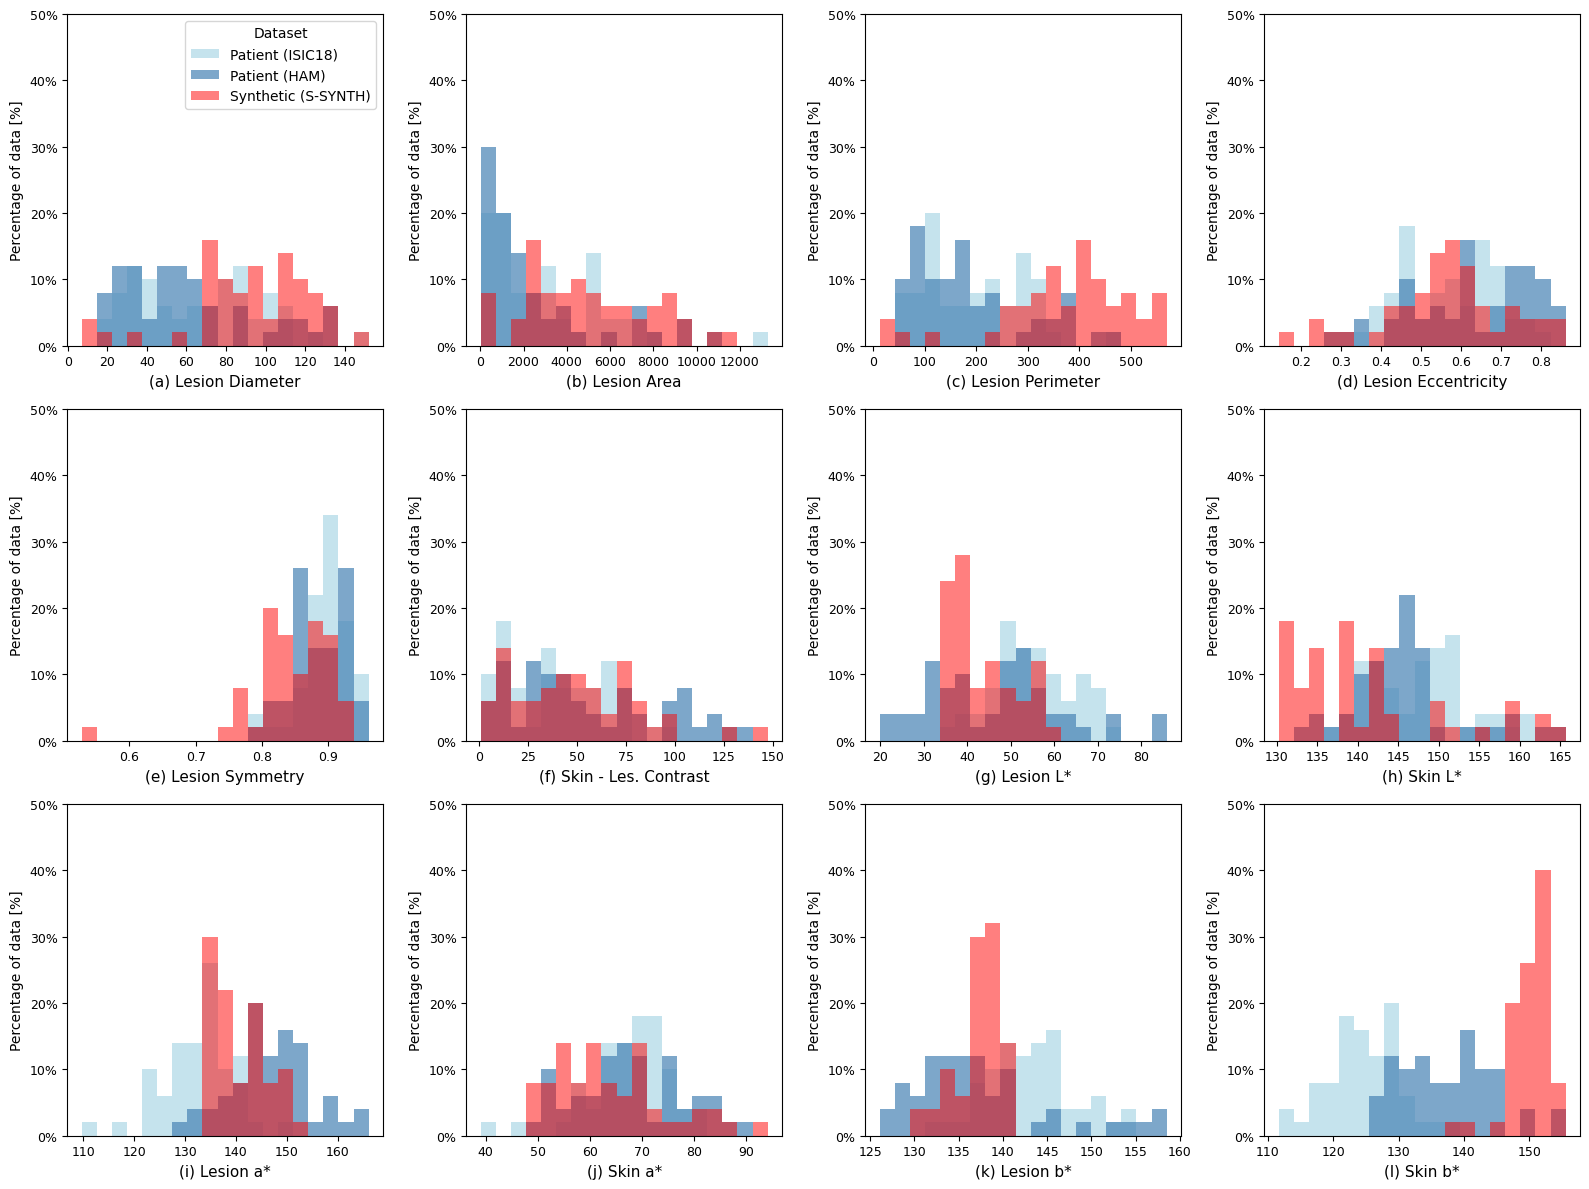

In [29]:
real_dataset0 = 'ISIC18'
real_dataset1 = 'HAM'

df_synth = pd.read_csv(save_dir + 'synth' + '.csv')
df_real0 = pd.read_csv(save_dir + 'HAM' + '.csv')
df_real1 = pd.read_csv(save_dir + 'ISIC' + '.csv')

features = ['diameter', 'area', 'perimeter', 'eccentircity', 'symmetry', 'contrast', 
            'lesion_l', 'lesion_a', 'lesion_b', 'skin_l', 'skin_a', 'skin_b']

# Feature labels for display
feature_labels = ['Lesion Diameter', 'Lesion Area', 'Lesion Perimeter', 'Lesion Eccentricity',
                  'Lesion Symmetry', 'Skin - Les. Contrast', 'Lesion L*', 'Skin L*',
                  'Lesion a*', 'Skin a*', 'Lesion b*', 'Skin b*']

legend_labels = ['Patient ('+real_dataset0+')',
                 'Patient ('+real_dataset1+')', 
                 'Synthetic (S-SYNTH)']

# Create 3x4 subplot figure
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    
    max_num = pd.concat([df_real0[feature], df_real1[feature], df_synth[feature]], axis=0).max()
    min_num = pd.concat([df_real0[feature], df_real1[feature], df_synth[feature]], axis=0).min()
    bins = np.linspace(min_num, max_num, 20)
    
    ax.hist(df_real0[feature], weights=np.ones_like(df_real0[feature]) / float(len(df_real0[feature])), 
            bins=bins, color='#add8e6', label=real_dataset0, alpha=0.7)
    ax.hist(df_real1[feature], weights=np.ones_like(df_real1[feature]) / float(len(df_real1[feature])), 
            bins=bins, color='#4682B4', label=real_dataset1, alpha=0.7)
    ax.hist(df_synth[feature], weights=np.ones_like(df_synth[feature]) / float(len(df_synth[feature])), 
            bins=bins, color='red', alpha=0.5, label='Synthetic')
    
    # Set x-axis label with subplot letter and feature name
    ax.set_xlabel(f'({chr(97+i)}) {feature_labels[i]}', fontsize=11)
    
    # Add legend only to first subplot
    if i == 0:
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(title='Dataset', handles=handles, labels=legend_labels, fontsize=10, title_fontsize=10)
    
    ax.set_ylabel('Percentage of data [%]', fontsize=10)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set_ylim([0, 0.5])
    ax.tick_params(axis='both', which='major', labelsize=9)

plt.tight_layout()
plt.show()